# Problem 1

In class we discussed the Thurber tumor spheroid model. Let’s use this model to evaluate different therapeutic options using an antibody-drug-conjugate (ADC). ADCs combine the molecular recognition of an antibody with a cytotoxic drug payload that can kill cells when the payload is internalized. We want to have as even concentration of drug across the tumor as possible. Consider a concentration of ADC in the plasma of 70 nM (approx. 10  $\mu$ g/mL for an IgG); ignore ADC depletion over time. The parameters for a tumor spheroid are below: 

| Parameter	| Estimate |
|-----------|----------|
| Ag per cell |	$1.5 \times 10^4$ (# per cell) |
| Ag concentration [Ag]	| $4.0 \times 10^{-9} M$ |
| Void fraction $\epsilon$	| 0.1537 |
| Endocytosis rate constant kec	| $1.6 \times 10{-5} s^{-1}$ |
| Tumor radius	| 1.5 cm |

We’re going to evaluate and rank two tunable parameters – the antibody size and the antibody affinity for the antigen (Ag). 

## Problem 1a.	
Consider the following different antibody frameworks with associated molecular weights. Assume all bind to the antigen monovalently at a $K_d = 10$ nM. Neglect the impact of the drug on the Stokes radius of the ADC. 

| Antibody | Estimated Molecular Weight [kDa] |	Stokes (hydrodynamic) radius [nm] |
|----------|----------------------------------|-----------------------------------|
| Nanobody | 12	| 1.7 |
| scFv | 25	| 2.2 |
| Fab |	50	| 3.1 |
| IgG |	150	| 4.7 |

Using these estimated Stokes radii, first estimate the Thiele modulus of each ADC. Next, plot the tumor penetration of each ADC as a function of tumor radial distance (ADC concentration Y axis; tumor radius X axis). Assume the viscosity of the tumor to be similar to blood (4 cP). 

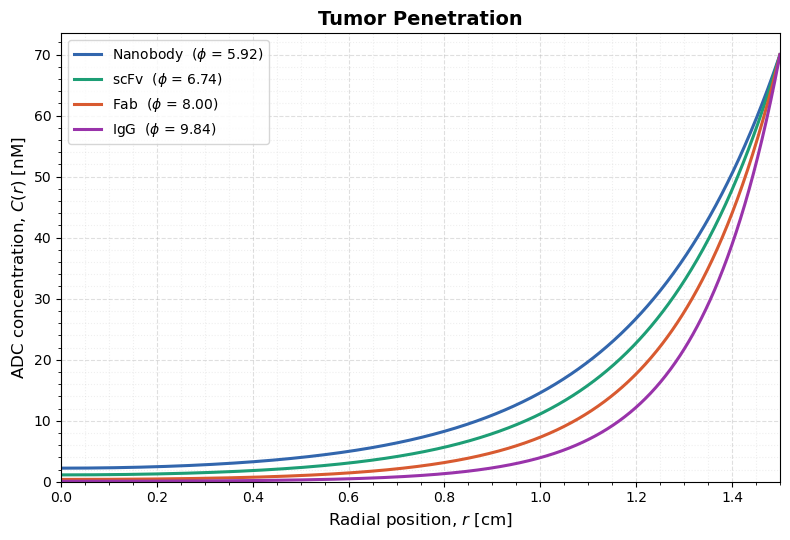

Antibody          phi
----------------------
Nanobody         5.92
scFv             6.74
Fab              8.00
IgG              9.84


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Physical constants ────────────────────────────────────────────────────────
kB = 1.380649e-23       # Boltzmann constant      [J/K]
T  = 310.15             # Body temperature         [K]  (37 °C)

# ── Model parameters ─────────────────────────────────────────────────────────
eta     = 4e-3          # Viscosity (blood/tumor)  [Pa·s]  (4 cP)
epsilon = 0.1537        # Void fraction            [dimensionless]
R       = 1.5e-2        # Tumor radius             [m]
kec     = 1.6e-5        # Endocytosis rate const   [s⁻¹]
Ag      = 4.0e-9        # Antigen concentration    [mol/L]
Kd      = 10e-9         # Dissociation constant    [mol/L]
C0      = 70e-9         # Plasma ADC concentration [mol/L]

# Convert mol/L → mol/m³ for SI consistency
Ag_SI = Ag * 1e3
Kd_SI = Kd * 1e3
C0_SI = C0 * 1e3

# ── Antibody formats ──────────────────────────────────────────────────────────
antibodies = [
    {"name": "Nanobody", "mw_kDa": 12,  "rs_nm": 1.7, "color": "#3266ad", "ls": "-"},
    {"name": "scFv",     "mw_kDa": 25,  "rs_nm": 2.2, "color": "#1D9E75", "ls": "-"},
    {"name": "Fab",      "mw_kDa": 50,  "rs_nm": 3.1, "color": "#D85A30", "ls": "-"},
    {"name": "IgG",      "mw_kDa": 150, "rs_nm": 4.7, "color": "#9933aa", "ls": "-"},
]

# ── Radial grid ───────────────────────────────────────────────────────────────
xi   = np.linspace(1e-4, 1.0, 1000)    # normalised radius r/R
r_cm = xi * R * 100                     # physical radius [cm]

# ── Compute ────────────────────────────────────────────────────────

for ab in antibodies:
    rs   = ab["rs_nm"] * 1e-9
    D    = kB * T / (6 * np.pi * eta * rs)     # [m²/s]
    Deff = D * epsilon                           # [m²/s]

    phi  = np.sqrt(kec * Ag_SI * R**2 / (Deff * (Kd_SI + C0_SI)))

    C_profile_nM = (C0 * 1e9) * np.sinh(phi * xi) / (xi * np.sinh(phi))
    C_center_nM  = (C0 * 1e9) * phi / np.sinh(phi)

    ab.update({
        "D_cm2s": D * 1e4, "Deff_cm2s": Deff * 1e4,
        "phi": phi, "C_profile_nM": C_profile_nM, "C_center_nM": C_center_nM
    })


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))

for ab in antibodies:
    r_plot = np.concatenate([[0],        r_cm])
    C_plot = np.concatenate([[ab["C_center_nM"]], ab["C_profile_nM"]])
    ax.plot(r_plot, C_plot,
            label=rf"{ab['name']}  ($\phi$ = {ab['phi']:.2f})",
            color=ab["color"], linestyle=ab["ls"], linewidth=2.2)

ax.set_xlabel("Radial position, $r$ [cm]", fontsize=12)
ax.set_ylabel("ADC concentration, $C(r)$ [nM]", fontsize=12)
ax.set_title("Tumor Penetration", fontsize=14, fontweight="bold")
ax.set_xlim(0, R * 100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10, loc="upper left")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", ls="--", alpha=0.4)
ax.grid(True, which="minor", ls=":",  alpha=0.2)

plt.tight_layout()
plt.show()

# Table of results
print(f"{'Antibody':<12} {'phi':>8}")
print("-" * 22)
for ab in antibodies:   
    print(f"{ab['name']:<12} {ab['phi']:>8.2f}")

## Problem 1b.

You should find that, of the antibody formats considered, the nanobody has the most potent tumor penetration. In class I asserted that one wants a therapeutic antibody with a worse (higher) dissociation constant than you would otherwise consider for therapeutic applications. In the context of this model, determine the dissociation constant of the $K_d$ in which cell killing is maximal in the center of the tumor spheroid. To accomplish this, let’s assume that the rate of drug internalized per cell is proportional to cell killing activity. Under this assumption, write the analytical expression for the amount of drug internalized per cell per time as a function of the nanobody dissociation constant in the limit where r $\to$ 0 (take r = 0.001R). Then, determine the optimal $K_d$ for this system. 

Drug Internalization: 

$ r_{\text{int}} = \frac{[Ag]}{\epsilon} \cdot \left( \frac{[Ab]}{[Ab] + K_d}\right)k_{ec} \left( [Ab](r) \right) = \frac{[Ag]}{\epsilon} \cdot \left( \frac{[Ab]}{[Ab] + K_d}\right)k_{ec} \left( [Ab]_{\text{plasma}}\Psi (\lambda(r)) \right) $

Where: $\lambda = \frac{r}{R}, 0 < \lambda < 1, \quad \& \quad \Psi = \frac{[Ab]}{[Ab]_{plasma}}$

In [2]:
import numpy as np

kB = 1.380649e-23
T  = 310.15      
epsilon = 0.1537
R = 1.5e-2
kec = 1.6e-5
Ag_M = 4.0e-9
Ag_per_cell = 1.5e4 
Ab_plasma = 70e-9 
rs_nanobody = 1.7   

def diffusion_coefficient(rs_nm):
    """Stokes-Einstein free diffusivity [m^2/s]."""
    eta  = 4e-3
    rs_m = rs_nm * 1e-9
    return kB * T / (6 * np.pi * eta * rs_m)

D = diffusion_coefficient(rs_nanobody)
Deff = D * epsilon 

def thiele_mod(Kd):
    """
    phi(Kd) = R * sqrt( kec*[Ag] / (Deff*(Kd + Ab_plasma)) )
    """
    Ag_SI        = Ag_M      * 1e3
    Kd_SI        = Kd        * 1e3
    Ab_plasma_SI = Ab_plasma * 1e3
    return np.sqrt((kec * Ag_SI * R**2) / (Deff * (Kd_SI + Ab_plasma_SI)))

def thurber(lam, Kd):
    """
    Ab(r) = Ab_plasma * Psi(lambda, Kd)
    """
    phi = thiele_mod(Kd)
    if np.isscalar(lam):
        psi = phi / np.sinh(phi) if lam < 1e-6 else \
              np.sinh(phi * lam) / (lam * np.sinh(phi))
    else:
        psi = np.where(
            lam < 1e-6,
            phi / np.sinh(phi),
            np.sinh(phi * lam) / (lam * np.sinh(phi))
        )
    return Ab_plasma * psi

def rate_of_internalization(Kd):
    """
    R_intern(Kd) = kec * [Ag/cell] * Ab(0,Kd) / (Ab(0,Kd) + Kd)
    """
    Ab_center = thurber(0.0, Kd)   # evaluate at lam=0 (tumour centre)
    return kec * Ag_per_cell * Ab_center / (Ab_center + Kd)

Kd_values = np.logspace(-12, -3, 1500)   # mol/L  (1 fM to 1 mM)
lam = np.linspace(0, 1, 1500)      # normalised radius (for plotting profiles)

rates = np.array([rate_of_internalization(Kd) for Kd in Kd_values])
idx_max = np.argmax(rates)
optimum_Kd = Kd_values[idx_max]

print(f"Optimal Kd: {optimum_Kd:.2e} M  ({optimum_Kd*1e9:.4f} nM)")

Optimal Kd: 1.00e-12 M  (0.0010 nM)


# Problem 2
Reaction/diffusion of a drug into a cell. Consider targeting of an antibiotic to a bacterium. The bacterium possesses an enzyme that can cleave the drug. The drug is efficacious at a steady state concentration of 200 $\mu M$.  The drug enters by passive diffusion and is cleaved by the enzyme according to the following rate: 

$rate [μM⁄s]=8 \cdot \frac{C_1}{(K_M+C_1)}$

Here C1 is the concentration of intracellular drug, Km is the Michaelis constant and approximately 50 $\mu\ M$. The permeability of the drug is not known but can be estimated using equation (1) from the following reference [here](https://doi.org/10.1016/S0169-409X(98)00090-8). The logP of the drug is 1.2. 

## Problem 2a. 
Write a mass balance on the intracellular concentration of the drug using the control volume of an intracellular bacterium (assume that you reach steady state before the cell divides). Assume a constant external concentration of the drug to be C2, and that the total mass of the drug extracellularly to be much larger than intracellularly.


From equation (1)

$\log P_c = -5.102 + 0.566 \times \log P_{o/w} = -5.102 + 0.566 \times 1.2$

$\log P_c = -5.102 + 0.679 = -4.423$

$P_c = 10^{-4.423} \approx 3.77 \times 10^{-5} \ \text{cm/s}$

Bacteria $\approx$ $V = \pi r^2 h$, $SA = 2 \pi r h + 2 \pi r^2$, with $r=0.25 \mu \text{m}\ \quad \& \quad h = 2\mu \text{m} $:

$\implies V = \pi \cdot (0.25)^2 \cdot 2 = 0.785 \mu \text{m}^3\ \quad \& \quad SA = 2 \cdot \pi \cdot (0.25) + 2 \cdot \pi \cdot (0.25)^2 = 3.14 \mu \text{m}^2$

Mass balance:

$\frac{d [C1]}{dt} = \frac{P_m SA}{V}[[C2] - [C1]] - \frac{8 [C1]}{K_M + [C1]}$

$\implies \frac{d [C_1]}{dt} = [C2] - [C1] - \frac{8 \cdot V \cdot [C1]}{P_M \cdot SA (K_d + [C1])} = [C2] - [C1] - \frac{6.28 [C1]}{60.79 +1.22[C1]}$


## Problem 2b.

Determine (a.) the external concentration of the drug necessary for it to be efficacious; and (b.) the approximate time to reach steady state under these conditions, starting with an initial C1 = 0. You may assume that the average surface area of the bacterium to be like that of E. coli. 

In [22]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

r_um   = 0.5;  L_um = 2.0               
SA_cm2 = 2 * np.pi * r_um * L_um * 1e-8 + (4 * np.pi * r_um**2) * 1e-8
V_cm3  = (np.pi*r_um**2*(L_um)) * 1e-12
SAV    = SA_cm2 / V_cm3

Pc     = 10**(-5.102 + 0.566 * 1.2)       
k      = Pc * SAV                         
Vmax   = 8.0;  Km = 50.0;  C1_eff = 200.0 

# At SS: k*(C2-C1) = Vmax*C1/(Km+C1)
# => C2 = C1 + Vmax*C1 / (k*(Km+C1))
enzyme_ss = Vmax * C1_eff / (Km + C1_eff)
C2_req    = C1_eff + enzyme_ss / k       

# Full ODE: dC1/dt = k*(C2 - C1) - Vmax*C1/(Km+C1)
# Linearise around C1_ss: dx/dt = -lambda*x
#   lambda = k + Vmax*Km/(Km+C1_ss)^2
d_enz = Vmax * Km / (Km + C1_eff)**2
lam   = k + d_enz                   
tau   = 1.0 / lam                   

def ode(t, y):
    C1 = y[0]
    return [k*(C2_req - C1) - Vmax*C1/(Km + C1)]

t_end  = 6 * tau
t_eval = np.linspace(0, t_end, 2000)
sol    = solve_ivp(ode, (0, t_end), [0.0], t_eval=t_eval, max_step=1e-4)
C1_t   = sol.y[0]
t_95   = sol.t[np.argmax(C1_t >= 0.95 * C1_eff)]

# Steady-state sweep for panel B
C2_sweep    = np.linspace(0, 600, 2000)
C1_ss_sweep = [brentq(lambda C1: k*(C2-C1) - Vmax*C1/(Km+C1), 0, C2+1e-9)
               for C2 in C2_sweep]
C1_ss_sweep = np.array(C1_ss_sweep)

print(f'Time to reach 95% of C1_ss: t_95 = {t_95:.3f} s (≈ {t_95*1e3:.1f} ms)')
print(f'C2 at SS = {C2_req:.2f} uM')



Time to reach 95% of C1_ss: t_95 = 1.317 s (≈ 1316.6 ms)
C2 at SS = 202.82 uM


# Problem 3

Draft a 1-page abstract of your final project. This should be written as a prospectus in which you state the system you which to analyze or model, the significance of the system (why are you interested in this system?), the type of analysis performed, and expected results. These types of projects work best when they relate somehow to your major thesis project, and I strongly encourage some overlap! This abstract should be 250-300 words with a graphical abstract similar to ACS publications. I strongly encourage you to discuss the project with me ahead of the PS due date. 

### Abstract

--- 
Working Title: An Ordinary Differential Equations Framework for Lipoprotein(a) Expression Dynamics as a Function of Copy Number Variation Length 

Lipoprotein(a) [Lp(a)] is a highly atherogenic, prothrombotic, and proinflammatory lipoprotein with well-established causal associations with cardiovascular disease (CVD) risk. A defining feature of Lp(a) is the Kringle IV Type 2 (KIV-2) variable number tandem repeat (VNTR) region within the *LPA* gene, which encodes the apolipoprotein(a) [apo(a)] protein. KIV-2 copy number ranges from 1–40 repeats and accounts for 40–70% of variation in circulating Lp(a) concentrations, with shorter repeat lengths typically associated with higher endogenous Lp(a) concentrations. Despite >70% heritability and co-dominant structure, the mechanistic basis for this inverse relationship remains incompletely understood. The prevailing hypothesis implicates endoplasmic reticulum (ER) protein trafficking as the central regulatory bottleneck. Longer apo(a) isoforms require more extensive post-translational modification, before export, in turn, increasing exposure to ER-associated degradation (ERAD) machinery. This project develops an ordinary differential equation (ODE) model of apo(a) synthesis, folding, trafficking, and degradation as a function of KIV-2 repeat number. The model will incorporate: (1) isoform-length-dependent ER processing rates, (2) ERAD-mediated degradation as a function of ER processing time, and (3) secretion and hepatic assembly into Lp(a) particles. Expected results include steady-state apo(a) secretion curves as a function of repeat number that recapitulate the experimentally observed inverse relationship between KIV-2 copy number and Lp(a) concentration. Bifurcation and sensitivity analyses will identify rate-limiting steps in trafficking and degradation, with implications for therapeutic targeting of Lp(a) biosynthesis. Broadly, this framework may inform haplotype informed polygenic risk score construction for Lp(a)-associated CVD, supporting more equitable cardiovascular risk prediction across genetically diverse populations.

### Graphical Abstract
---
Figure will be updated upon deadline of this specific problem which is not due until April 9th. 
---

![Insert Image Here](LMM.gif "Title")

# Location of Jupyter Notebook

This file was created in jupyter notebook, rendered into `.html` through `jupyter nbconvert --to html PS10/PS10.ipynb` then the `.html` file was saved as a `.pdf`. The location of all said files are [github.com/caterer-z-t/CHEN_5150/PS10](https://github.com/caterer-z-t/CHEN_5150/tree/main/PS10)

Please contact [ztcaterer@colorado.edu](mailto:ztcaterer@colorado.edu) if there are any issues or concerns. 

Thanks :-)

### Disclosure
Generative artificial intelligence tools were used to assist with this project. All generated content was reviewed, edited, and verified by the authors, who take full responsibility for the accuracy, integrity, and final content of this work. 